In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import quad
from numpy.polynomial.legendre import leggauss

### Part (a)

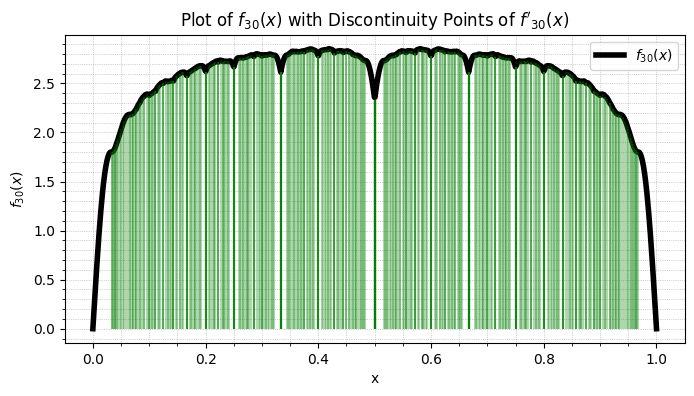

Total number of discontinuity points:  495


In [11]:
# Defining the function fn(x)
def fn(x, n):
    result = 0
    for j in range(1, n + 1):
        result += np.abs(np.sin(j * np.pi * x))/j
    return result


# number of terms
n = 30

# Generating x values
x = np.linspace(0, 1, 1000, endpoint=True)

# Calculateing fn(x)
y = fn(x, n)

# Plotting fn(x)
plt.figure(figsize=(8, 4))
plt.plot(x, y, label='$f_{30}(x)$', lw=4, color='black')

# Ploting vertical lines at discontinuity points
num_dis = 0
d = 0.00001  # to include upper limit of domain
for j in range(1, n+1):
    discontinuity_points = np.arange(0, 1+d, 1/j)
    num_dis = num_dis + len(discontinuity_points)
    plt.vlines(discontinuity_points, 0, fn(discontinuity_points, n), colors='green', alpha=.3)


plt.title('Plot of $f_{30}(x)$ with Discontinuity Points of $f\'_{30}(x)$')
plt.xlabel('x')
plt.ylabel('$f_{30}(x)$')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.show()

print("Total number of discontinuity points: ", num_dis)


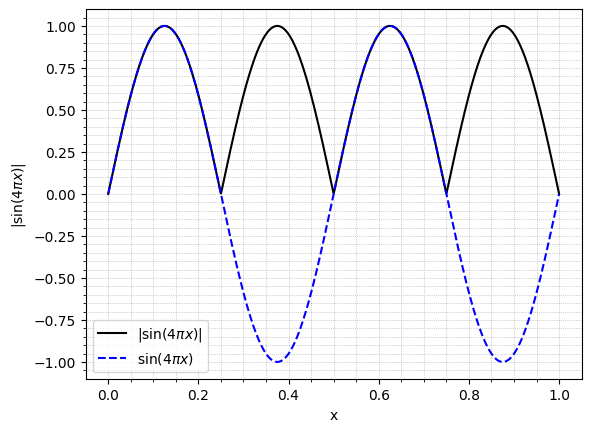

In [4]:
# plot to display symmetry of |sin(4*pi*x)|
plt.plot(x,np.abs(np.sin(4*np.pi*x)), color='black', label='$|\sin(4\pi x)|$')
plt.plot(x,(np.sin(4*np.pi*x)), color='blue', linestyle='--', label='$\sin(4\pi x)$')
plt.xlabel('x')
plt.ylabel('$|\sin(4\pi x)|$')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.legend()
plt.show()

### Part (b)

In [5]:
def trapezoidal_rule(f, a, b, n):
    '''-----------------------------------------
    Function to impolement the trapezoidal rule
    
    Parameters:
        f - function to be integrated
        a - lower limit of integral
        b - lower limit of integral
        n - number of subintervals.
    
    Return:
        - Result of integration.
    --------------------------------------------'''
    
    # step size
    h = (b - a) / n
    
    # value of function at end points
    integral = 0.5 * (f(a) + f(b))
    
    # perform trapezoidal integration at internal points
    for i in range(1, n):
        integral += f(a + i * h)
    
    integral = h * integral
    return integral

In [12]:
# limits of integration
a = 0
b = 1

# number of subintervals
n = 50  

# Approximation using trapezoidal rule
approx_integral = trapezoidal_rule(lambda x: fn(x, 30), a, b, n)

# Approximation of integral using quad
approx_integral_quad, e = quad(lambda x: fn(x, 30), a, b)

print("Approximated integral using Trapezoidal Rule:", approx_integral)
print("Approximated integral using quad: ", approx_integral_quad)
print("Error using quad: ", e)

Approximated integral using Trapezoidal Rule: 2.5308975159364078
Approximated integral using quad:  2.543363181357029
Error using quad:  0.0008220285960751639


/tmp/ipykernel_2010754/3441753484.py:12: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  approx_integral_quad, e = quad(lambda x: fn(x, 30), a, b)


In [13]:
def gaussian_quadrature(f, a, b, n_points):
    '''------------------------------------------------------------------------
    Approximates the definite integral of a function using Gaussian quadrature.

    Parameters:
        f        : The integrand, a function of one variable.
        a        : The lower limit of integration.
        b        : The upper limit of integration.
        n_points : The number of quadrature points.

    Returns:
        The approximate value of the integral.    
    ---------------------------------------------------------------------------'''
    
    # Get the Gaussian quadrature nodes and weights
    nodes, weights = leggauss(n_points)
    
    # Transform nodes and weights 
    transformed_nodes = 0.5 * (nodes + 1) * (b - a) + a
    transformed_weights = 0.5 * (b - a) * weights
    return np.sum(transformed_weights * f(transformed_nodes))


# Approximation of integral using Gaussian quadrature
approx_integral_gaussian = gaussian_quadrature(lambda x: fn(x, 30), a, b, n)
print("Approximated integral using Gaussian quadrature: ", approx_integral_gaussian)

Approximated integral using Gaussian quadrature:  2.542204387079397


### Part (c)

Total sum: 2.5432877978979564


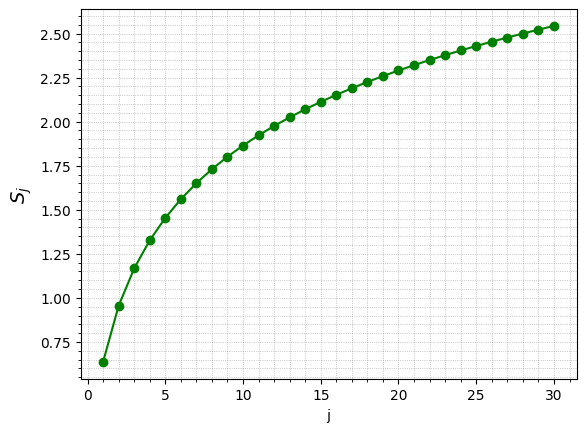

In [14]:
# Initializing the sum
sum = 0.0
sum_values = []

# Loop to compute the sum and store intermediate values
for i in range(1, 31):
    sum += 2.0 / (i * np.pi)
    sum_values.append(sum)

# Printing the final sum
print("Total sum:", sum)

# Plotting the sum values
plt.plot(range(1, 31), sum_values, marker='o', color='green')
plt.xlabel('j')
plt.ylabel('$S_j$', fontsize= 14)
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
plt.show()